**Experiment C**

In [2]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 7.1 MB/s eta 0:00:00


In [3]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy

import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt


# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def cleanup_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [4]:
# Cell 3 — Dataset: CIFAR-10 + loaders
# IID CIFAR-10 setup

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616))
])

train_ds = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("dataset: CIFAR-10")
print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 170M/170M [00:04<00:00, 39.9MB/s]


dataset: CIFAR-10
train: 50000 test: 10000


In [5]:
# Cell 4 — PUBLIC set + IID clients
# Public points removed from private client datasets.
# IID disjoint client construction for CIFAR-10.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [
        perm[i * samples_per_client:(i + 1) * samples_per_client].tolist()
        for i in range(num_clients)
    ]

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

clients = build_iid_clients_from_indices(
    avail_idx,
    NUM_CLIENTS,
    SAMPLES_PER_CLIENT,
    seed=0
)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 49800
NUM_CLIENTS: 4980 | samples/client: 10 | clients/round: 100
q = 0.020080321285140562


In [6]:
# Cell 6 — Model + evaluation
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32x32 -> 16x16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Keep this name so the rest of the notebook does not need to change
FMNIST_CNN = CIFAR10_CNN

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [7]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t * t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a * b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out

In [8]:
# Cell 8 — Local client update
# Local client update (SGD) returns delta = (local - global)
# LF is interpreted as label flipping with cyclic shift y -> (y + 1) % NUM_CLASSES.

loss_fn = nn.CrossEntropyLoss()

def maybe_flip_labels(y, shift=1):
    return (y + int(shift)) % NUM_CLASSES

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  label_flip=False, label_flip_shift=1):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, client_indices),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if label_flip:
                y = maybe_flip_labels(y, shift=label_flip_shift)

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())

    del local_model
    return delta

In [9]:
# Cell 9 — DP accounting (RDP) + sigma search
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.
# AG-PTR interpretation in this version:
#   - sigma_sel and sigma_rel are NOISE MULTIPLIERS
#   - add/remove adjacency
#   - selection sensitivity = 1
#   - release sensitivity = rho / m_hat <= rho / tau
#   - implementation adds noise AFTER normalization with std = sigma_rel * rho / m_hat

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    try:
        return rdp_analysis.compute_rdp(
            q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders
        )
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(
            orders=orders, rdp=rdp, delta=delta
        )
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sigma_sel = sel_factor * sigma_rel
    lo, hi = 1e-4, 1.0

    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor * sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

In [10]:
# Cell 10 — Attack helpers
# Byzantine attack helpers for:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Notes:
# - LF is implemented as label flipping and handled inside the train_* functions.
# - SF here is a sign-flip style update attack.
# - FoE here is an inner-product-manipulation / negative-mean style attack.

def normalize_attack_name(name):
    return str(name).strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def is_label_flip_attack(name):
    return normalize_attack_name(name) in {"lf", "labelflip", "labelflipping"}

@torch.no_grad()
def mean_update_list(update_list):
    if len(update_list) == 0:
        raise ValueError("No updates available.")
    P = len(update_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in update_list], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def _pairwise_sq_dists(X):
    gram = X @ X.t()
    diag = torch.diag(gram).unsqueeze(1)
    D = diag + diag.t() - 2.0 * gram
    return D.clamp_min(0.0)

@torch.no_grad()
def _deviation_vec(X):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False)

    dev = sd * torch.sign(mu)
    if torch.norm(dev) < 1e-12:
        dev = mu.clone()
    if torch.norm(dev) < 1e-12:
        dev = torch.ones_like(mu)

    dev = dev / (torch.norm(dev) + 1e-12)
    return mu, dev

def _search_lambda(valid_fn, hi_init=1.0, iters=40):
    lo, hi = 0.0, float(hi_init)

    while valid_fn(hi):
        lo = hi
        hi *= 2.0
        if hi > 1e6:
            break

    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        if valid_fn(mid):
            lo = mid
        else:
            hi = mid

    return float(lo)

@torch.no_grad()
def _attack_vec_alie(X, z=2.0, direction=-1.0):
    mu = X.mean(dim=0)
    sd = X.std(dim=0, unbiased=False) + 1e-12
    return mu + float(direction) * float(z) * sd

@torch.no_grad()
def _attack_vec_sf(X, scale=5.0):
    mu = X.mean(dim=0)
    mean_abs = X.abs().mean(dim=0) + 1e-12
    return -float(scale) * torch.sign(mu) * mean_abs

@torch.no_grad()
def _attack_vec_foe(X, scale=1.0):
    mu = X.mean(dim=0)
    return -float(scale) * mu

@torch.no_grad()
def _attack_vec_minmax(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.max().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def _attack_vec_minsum(X):
    mu, dev = _deviation_vec(X)
    D = _pairwise_sq_dists(X)
    thr = float(D.sum(dim=1).max().item())
    x_norm_sq = (X * X).sum(dim=1)

    def valid_fn(lam):
        c = mu - float(lam) * dev
        c_norm_sq = (c * c).sum()
        sq = x_norm_sq + c_norm_sq - 2.0 * (X @ c)
        return float(sq.sum().item()) <= thr + 1e-8

    lam = _search_lambda(valid_fn)
    return mu - lam * dev

@torch.no_grad()
def build_byzantine_vecs_from_honest(honest_vecs, byz_count,
                                     attack_type="alie",
                                     alie_z=2.0, alie_direction=-1.0,
                                     sf_scale=5.0, foe_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("No honest updates available to build this attack.")

    X = torch.stack(honest_vecs, dim=0)
    attack_key = normalize_attack_name(attack_type)

    if attack_key == "alie":
        mal = _attack_vec_alie(X, z=alie_z, direction=alie_direction)
    elif attack_key == "sf":
        mal = _attack_vec_sf(X, scale=sf_scale)
    elif attack_key == "minmax":
        mal = _attack_vec_minmax(X)
    elif attack_key == "minsum":
        mal = _attack_vec_minsum(X)
    elif attack_key in {"foe", "ipm", "fallofempires"}:
        mal = _attack_vec_foe(X, scale=foe_scale)
    elif is_label_flip_attack(attack_key):
        raise ValueError("LF is handled inside the training functions, not from honest updates.")
    else:
        raise ValueError(f"Unknown attack_type={attack_type!r}")

    mal = mal.detach()
    return [mal.clone() for _ in range(byz_count)]

@torch.no_grad()
def build_byzantine_updates_from_honest(honest_updates, byz_count,
                                        attack_type="alie",
                                        alie_z=2.0, alie_direction=-1.0,
                                        sf_scale=5.0, foe_scale=1.0):
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates available to build this attack.")

    template = honest_updates[0]
    honest_vecs = [flatten_list(u) for u in honest_updates]
    mal_vecs = build_byzantine_vecs_from_honest(
        honest_vecs, byz_count,
        attack_type=attack_type,
        alie_z=alie_z, alie_direction=alie_direction,
        sf_scale=sf_scale, foe_scale=foe_scale
    )

    out = []
    for v in mal_vecs:
        out.append([t.detach().clone() for t in unflatten_like(v, template)])
    return out

In [11]:
# Cell 11 — DP-FedAvg with selectable attacks
def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           attack_type="alie",
                           alie_direction=-1.0, alie_z=2.0,
                           sf_scale=5.0, foe_scale=1.0,
                           label_flip_shift=1,
                           show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"DP-FedAvg {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_client_ids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [12]:
# Cell 12 — AG-PTR with selectable attacks
# This version matches:
#   - add/remove adjacency
#   - sigma_sel, sigma_rel are noise multipliers
#   - selection sensitivity = 1
#   - release sensitivity = rho / m_hat <= rho / tau
#   - normalize first, then add noise with std = sigma_rel * rho / m_hat

def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    """
    One small SGD run on a PUBLIC subset, starting from global_model.
    Returns delta_pub = (public_model - global_model) as list-of-tensors.
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(pub_batch_size, len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())

    del local_model
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    """
    Build R anchors from PUBLIC data:
      - sample a random public minibatch of size pub_batch
      - do a tiny SGD step (public_epochs)
      - anchor = pub_scale * delta_pub
    """
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()
        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 attack_type="alie",
                 alie_direction=-1.0, alie_z=2.0,
                 sf_scale=5.0, foe_scale=1.0,
                 label_flip_shift=1,
                 allow_zero=False,
                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)
    accept = 0

    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"AG-PTR {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        byz_client_ids, byz_slots = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            honest_updates.append(
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size
                )
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_updates = [
                    client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    for cid in byz_client_ids
                ]
            else:
                byz_updates = build_byzantine_updates_from_honest(
                    honest_updates, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
        else:
            byz_updates = []

        # ---- rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0)
                n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            continue

        if float(noisy_winner) < float(tau):
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        # Normalize first, then add release noise in mean space
        mean_offsets = [so / m_hat for so in sum_offsets]

        noise_std = (float(sigma_rel) * float(rho)) / float(m_hat)
        for j in range(len(mean_offsets)):
            mean_offsets[j].add_(torch.randn_like(mean_offsets[j]) * noise_std)

        mean_update = [a + mo for a, mo in zip(a_star, mean_offsets)]
        add_update_(model, mean_update, scale=1.0)

    acc = evaluate(model, test_loader)
    accept_rate = accept / rounds
    del model
    cleanup_cuda()
    return acc, accept_rate

In [13]:
# Cell 13 — FedVRDP with selectable attacks
@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         attack_type="alie",
                         alie_direction=-1.0, alie_z=2.0,
                         sf_scale=5.0, foe_scale=1.0,
                         label_flip_shift=1,
                         show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    if num_clients is None:
        num_clients = len(clients)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)
    attack_key = normalize_attack_name(attack_type)

    iterator = tqdm(
        range(rounds),
        desc=f"FedVRDP {str(attack_type).upper()} f={int(100*byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_vecs = []
        honest_slots = []
        byz_client_ids = []
        byz_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_client_ids.append(cid)
                byz_slots.append(j)
                continue

            dlt = client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
            v = flatten_list(dlt).to(device) * mask

            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v.detach())
            honest_slots.append(j)

        if b > 0:
            if is_label_flip_attack(attack_key):
                byz_vecs = []
                for cid in byz_client_ids:
                    dlt = client_update(
                        model, clients[cid], lr=lr_t, momentum=momentum,
                        local_epochs=local_epochs, batch_size=batch_size,
                        label_flip=True, label_flip_shift=label_flip_shift
                    )
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v.detach())
            else:
                byz_vecs = build_byzantine_vecs_from_honest(
                    honest_vecs, b,
                    attack_type=attack_key,
                    alie_z=alie_z, alie_direction=alie_direction,
                    sf_scale=sf_scale, foe_scale=foe_scale
                )
                clipped_byz = []
                for v in byz_vecs:
                    v = v * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    clipped_byz.append(v.detach())
                byz_vecs = clipped_byz
        else:
            byz_vecs = []

        updates = [None] * clients_per_round
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        mask = topk_mask_from_vec(avg_vec.detach(), k)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [14]:
# Cell 13.1 — Robust baseline helpers
# Helpers used by Median / Trimmed Mean / Krum / SparseFed-style baselines.

def build_round_updates(model, rng, byz_frac, lr_t, momentum,
                        local_epochs=1, batch_size=10,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1):
    """
    Build the full list of client updates for one round, including honest and Byzantine clients.
    Returns:
        updates: list length CLIENTS_PER_ROUND, each entry is a list-of-tensors update
        byz_count: integer number of Byzantine clients in this round
    """
    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

    b = int(round(byz_frac * clients_per_round))
    byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

    honest_updates, honest_slots = [], []
    byz_client_ids, byz_slots = [], []

    attack_key = normalize_attack_name(attack_type)

    for j, cid in enumerate(chosen):
        if j in byz_pos:
            byz_client_ids.append(cid)
            byz_slots.append(j)
            continue

        honest_updates.append(
            client_update(
                model, clients[cid], lr=lr_t, momentum=momentum,
                local_epochs=local_epochs, batch_size=batch_size
            )
        )
        honest_slots.append(j)

    if b > 0:
        if is_label_flip_attack(attack_key):
            byz_updates = [
                client_update(
                    model, clients[cid], lr=lr_t, momentum=momentum,
                    local_epochs=local_epochs, batch_size=batch_size,
                    label_flip=True, label_flip_shift=label_flip_shift
                )
                for cid in byz_client_ids
            ]
        else:
            byz_updates = build_byzantine_updates_from_honest(
                honest_updates, b,
                attack_type=attack_key,
                alie_z=alie_z, alie_direction=alie_direction,
                sf_scale=sf_scale, foe_scale=foe_scale
            )
    else:
        byz_updates = []

    updates = [None] * clients_per_round
    for upd, j in zip(honest_updates, honest_slots):
        updates[j] = upd
    for upd, j in zip(byz_updates, byz_slots):
        updates[j] = upd

    return updates, b


@torch.no_grad()
def stack_updates_cpu(update_list):
    """
    Convert a list of list-of-tensors updates into an [n_clients, d] CPU tensor.
    """
    return torch.stack(
        [flatten_list(upd).detach().cpu() for upd in update_list],
        dim=0
    )


@torch.no_grad()
def clip_flat_vec(vec, clip_C):
    nrm = torch.norm(vec) + 1e-12
    return vec * min(1.0, float(clip_C) / float(nrm))


@torch.no_grad()
def apply_flat_update_(model, flat_vec_cpu):
    """
    Apply a flattened update vector (stored on CPU) to the model.
    """
    template = zero_like_params(model)
    upd_list = unflatten_like(flat_vec_cpu.to(device), template)
    add_update_(model, upd_list, scale=1.0)


@torch.no_grad()
def coord_median_vec(mat):
    """
    Coordinate-wise median over rows of mat, shape [n, d].
    """
    return mat.median(dim=0).values


@torch.no_grad()
def trimmed_mean_vec(mat, trim_k):
    """
    Coordinate-wise trimmed mean over rows of mat, trimming trim_k smallest
    and trim_k largest values in each coordinate.
    """
    n = mat.size(0)
    trim_k = int(max(0, min(int(trim_k), (n - 1) // 2)))

    if trim_k == 0 or 2 * trim_k >= n:
        return mat.mean(dim=0)

    vals, _ = torch.sort(mat, dim=0)
    return vals[trim_k:n - trim_k].mean(dim=0)


@torch.no_grad()
def krum_select_vec(mat, byz_count):
    """
    Krum selection rule on flattened client updates.
    Score(i) = sum of squared distances to the n - f - 2 nearest neighbors.
    Returns the selected update vector.
    """
    n = mat.size(0)
    neighbor_count = max(1, min(n - 1, n - int(byz_count) - 2))

    sq = _pairwise_sq_dists(mat)

    scores = []
    for i in range(n):
        d = torch.cat([sq[i, :i], sq[i, i + 1:]])
        vals, _ = torch.topk(d, k=neighbor_count, largest=False)
        scores.append(vals.sum())

    scores = torch.stack(scores)
    idx = int(torch.argmin(scores).item())
    return mat[idx].clone()


@torch.no_grad()
def topk_sparsify_vec(vec, k):
    """
    Keep only the top-k coordinates (by magnitude).
    """
    d = vec.numel()
    k = min(int(k), d)

    out = torch.zeros_like(vec)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        out[idx] = vec[idx]
    return out

In [15]:
# Cell 13.2 — Median baseline
# Non-private coordinate-wise median aggregator.

def train_median_robust(seed, eps_total, byz_frac,
                        delta=1e-5,
                        rounds=30, local_epochs=10, batch_size=10,
                        lr0=0.125, lr_decay=0.99, momentum=0.5,
                        attack_type="alie",
                        alie_direction=-1.0, alie_z=2.0,
                        sf_scale=5.0, foe_scale=1.0,
                        label_flip_shift=1,
                        show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Median {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = coord_median_vec(mat)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [16]:
# Cell 13.3 — Trimmed Mean baseline
# Non-private coordinate-wise trimmed mean aggregator.

def train_trimmedmean_robust(seed, eps_total, byz_frac,
                             delta=1e-5,
                             rounds=30, local_epochs=10, batch_size=10,
                             lr0=0.125, lr_decay=0.99, momentum=0.5,
                             trim_k=None,   # if None, use the actual byzantine count b each round
                             attack_type="alie",
                             alie_direction=-1.0, alie_z=2.0,
                             sf_scale=5.0, foe_scale=1.0,
                             label_flip_shift=1,
                             show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"TrimmedMean {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        trim_this_round = b if trim_k is None else int(trim_k)
        agg_vec = trimmed_mean_vec(mat, trim_this_round)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [17]:
# Cell 13.4 — Krum baseline
# Non-private Krum aggregator.
# Note: Krum's formal guarantee requires n > 2f + 2, but the score is still computable
# for all f values used in this smoke test.

def train_krum_robust(seed, eps_total, byz_frac,
                      delta=1e-5,
                      rounds=30, local_epochs=10, batch_size=10,
                      lr0=0.125, lr_decay=0.99, momentum=0.5,
                      attack_type="alie",
                      alie_direction=-1.0, alie_z=2.0,
                      sf_scale=5.0, foe_scale=1.0,
                      label_flip_shift=1,
                      show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    iterator = tqdm(
        range(rounds),
        desc=f"Krum {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, b = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)
        agg_vec = krum_select_vec(mat, b)
        apply_flat_update_(model, agg_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

In [18]:
# Cell 13.5 — SparseFed-style baseline
# Non-private simplified SparseFed-style baseline:
#   1) device-level clipping on client updates
#   2) average
#   3) global top-k sparsification of the averaged update

def train_sparsefed_style_robust(seed, eps_total, byz_frac,
                                 delta=1e-5,
                                 rounds=30, local_epochs=10, batch_size=10,
                                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                                 clip_C=1.0, k_frac=0.30,
                                 attack_type="alie",
                                 alie_direction=-1.0, alie_z=2.0,
                                 sf_scale=5.0, foe_scale=1.0,
                                 label_flip_shift=1,
                                 show_progress=True):

    seed_all(seed)
    rng = np.random.RandomState(seed)
    model = FMNIST_CNN().to(device)

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    iterator = tqdm(
        range(rounds),
        desc=f"SparseFed-style {str(attack_type).upper()} f={int(100 * byz_frac)}%",
        disable=not show_progress
    )

    for t in iterator:
        lr_t = lr0 * (lr_decay ** t)

        updates, _ = build_round_updates(
            model, rng, byz_frac, lr_t, momentum,
            local_epochs=local_epochs, batch_size=batch_size,
            attack_type=attack_type,
            alie_direction=alie_direction, alie_z=alie_z,
            sf_scale=sf_scale, foe_scale=foe_scale,
            label_flip_shift=label_flip_shift
        )

        mat = stack_updates_cpu(updates)

        clipped_rows = []
        for i in range(mat.size(0)):
            clipped_rows.append(clip_flat_vec(mat[i], clip_C))
        clipped_mat = torch.stack(clipped_rows, dim=0)

        avg_vec = clipped_mat.mean(dim=0)
        sparse_vec = topk_sparsify_vec(avg_vec, k)

        apply_flat_update_(model, sparse_vec)

    acc = evaluate(model, test_loader)
    del model
    cleanup_cuda()
    return acc, 1.0

Experiment: cifar10_iid
sigma_dp: 0.8267785803312031 achieved eps≈ 1.9999999999999987
sigma_ag sel/rel: 1.6545447874026284 0.8272723937013142 achieved eps≈ 1.9999999999999973
seed=0, rounds=5, local_epochs=1, batch_size=10
AG-PTR: rho=0.3, tau=35, R_pub_avg=16, pub_batch=80, pub_scale=0.002
ALIE: z=2.0, dir=-1.0
SF scale=5.0, FoE scale=1.0, LF shift=1
FedVRDP-style: clip_C=0.5, k_frac=0.3
SparseFed-style: clip_C=1.0, k_frac=0.3

==================== Attack: ALIE ====================
Saved expC_cifar10_iid_smoke_alie.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg,0.00,0.1748,NaN
1,ALIE,DP-FedAvg,0.10,0.1589,NaN
2,ALIE,DP-FedAvg,0.20,0.1361,NaN
3,ALIE,DP-FedAvg,0.30,0.1234,NaN
4,ALIE,DP-FedAvg,0.40,0.1140,NaN
5,ALIE,DP-FedAvg,0.49,0.1074,NaN
6,ALIE,DP-FedAvg,0.60,0.1052,NaN
7,ALIE,FedVRDP-style,0.00,0.1601,NaN
8,ALIE,FedVRDP-style,0.10,0.1695,NaN
9,ALIE,FedVRDP-style,0.20,0.1373,NaN


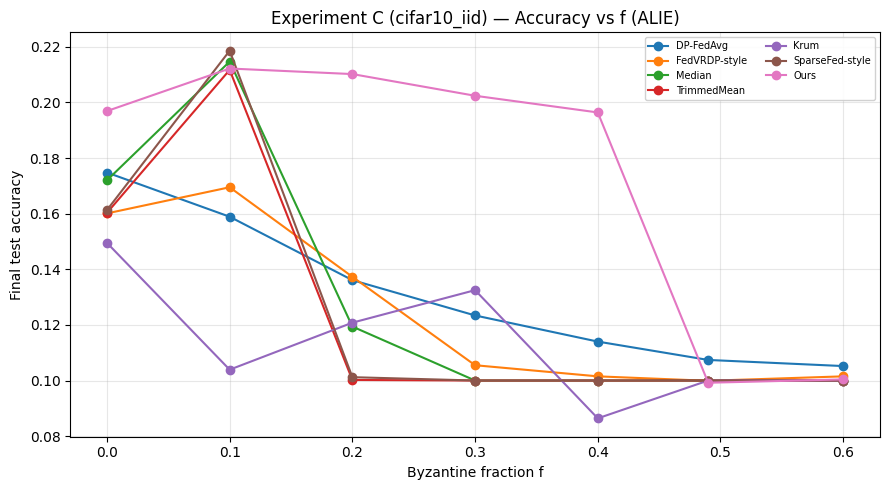

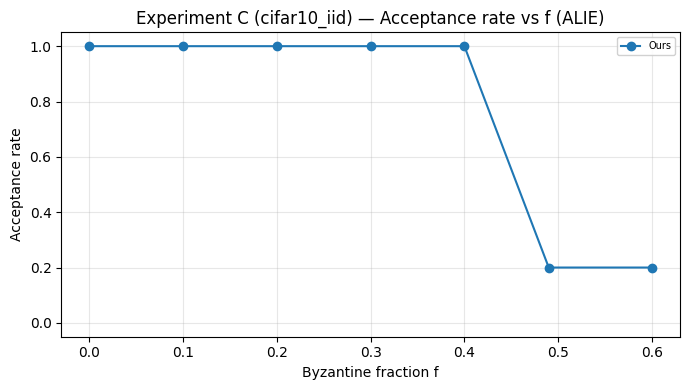


==================== Attack: SF ====================
Saved expC_cifar10_iid_smoke_sf.csv


,attack,method,f,acc,accept_rate
0,SF,DP-FedAvg,0.00,0.1748,NaN
1,SF,DP-FedAvg,0.10,0.0962,NaN
2,SF,DP-FedAvg,0.20,0.0850,NaN
3,SF,DP-FedAvg,0.30,0.0744,NaN
4,SF,DP-FedAvg,0.40,0.0563,NaN
5,SF,DP-FedAvg,0.49,0.1000,NaN
6,SF,DP-FedAvg,0.60,0.1000,NaN
7,SF,FedVRDP-style,0.00,0.1601,NaN
8,SF,FedVRDP-style,0.10,0.1030,NaN
9,SF,FedVRDP-style,0.20,0.1000,NaN


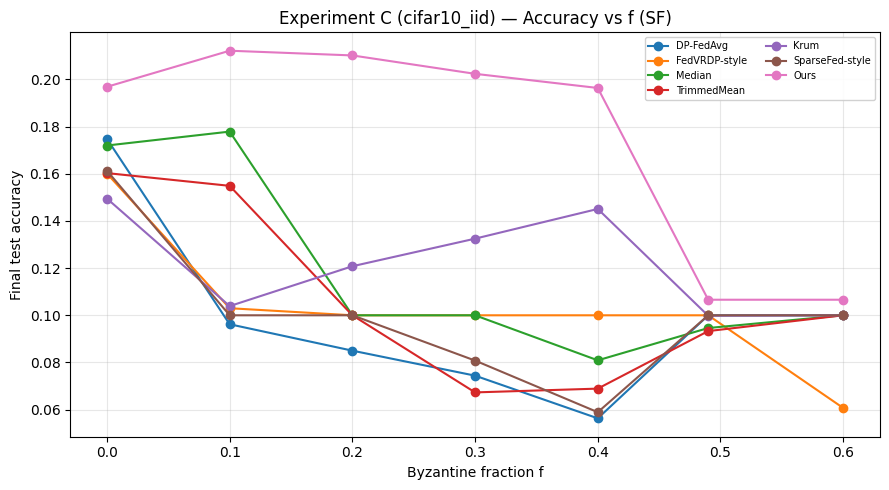

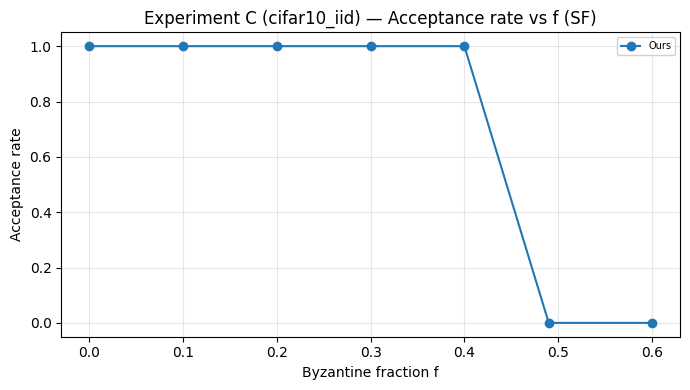


==================== Attack: MinMax ====================
Saved expC_cifar10_iid_smoke_minmax.csv


,attack,method,f,acc,accept_rate
0,MinMax,DP-FedAvg,0.00,0.1748,NaN
1,MinMax,DP-FedAvg,0.10,0.1625,NaN
2,MinMax,DP-FedAvg,0.20,0.1053,NaN
3,MinMax,DP-FedAvg,0.30,0.0971,NaN
4,MinMax,DP-FedAvg,0.40,0.0798,NaN
5,MinMax,DP-FedAvg,0.49,0.0911,NaN
6,MinMax,DP-FedAvg,0.60,0.1055,NaN
7,MinMax,FedVRDP-style,0.00,0.1601,NaN
8,MinMax,FedVRDP-style,0.10,0.1552,NaN
9,MinMax,FedVRDP-style,0.20,0.1279,NaN


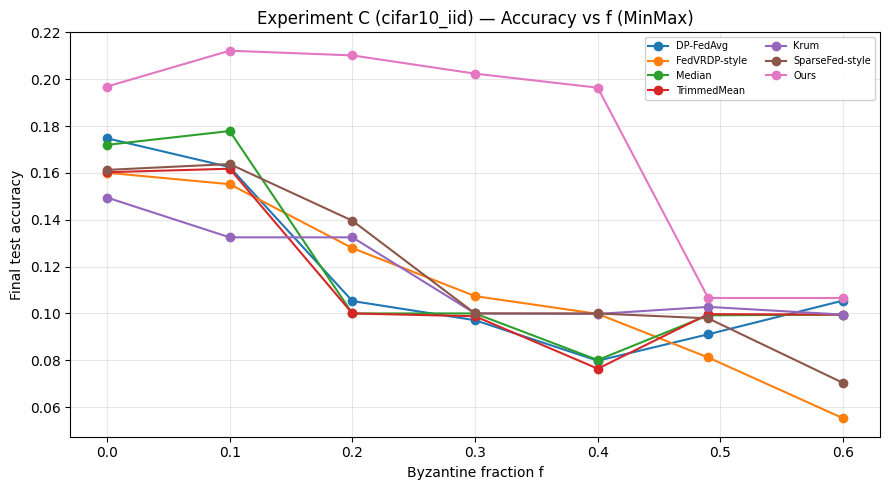

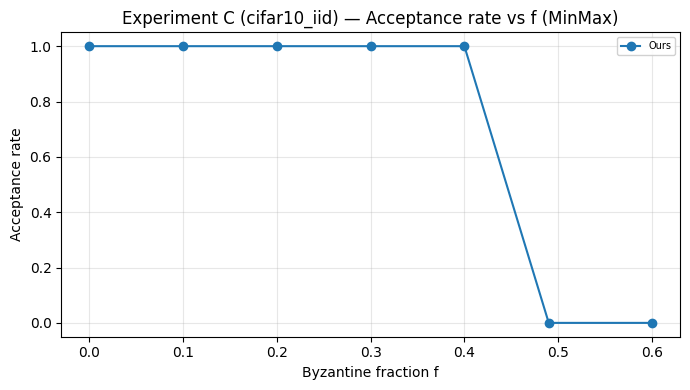


==================== Attack: MinSum ====================
Saved expC_cifar10_iid_smoke_minsum.csv


,attack,method,f,acc,accept_rate
0,MinSum,DP-FedAvg,0.00,0.1748,NaN
1,MinSum,DP-FedAvg,0.10,0.1648,NaN
2,MinSum,DP-FedAvg,0.20,0.1014,NaN
3,MinSum,DP-FedAvg,0.30,0.0940,NaN
4,MinSum,DP-FedAvg,0.40,0.0939,NaN
5,MinSum,DP-FedAvg,0.49,0.1020,NaN
6,MinSum,DP-FedAvg,0.60,0.1017,NaN
7,MinSum,FedVRDP-style,0.00,0.1601,NaN
8,MinSum,FedVRDP-style,0.10,0.1548,NaN
9,MinSum,FedVRDP-style,0.20,0.1129,NaN


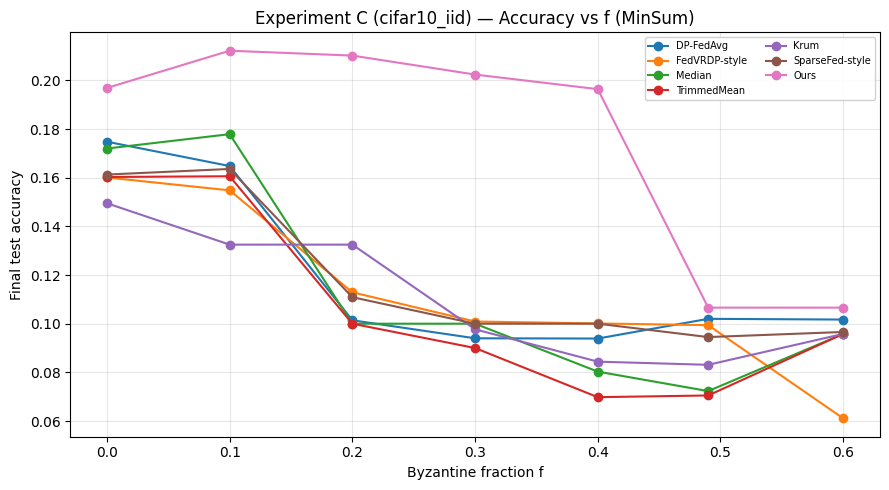

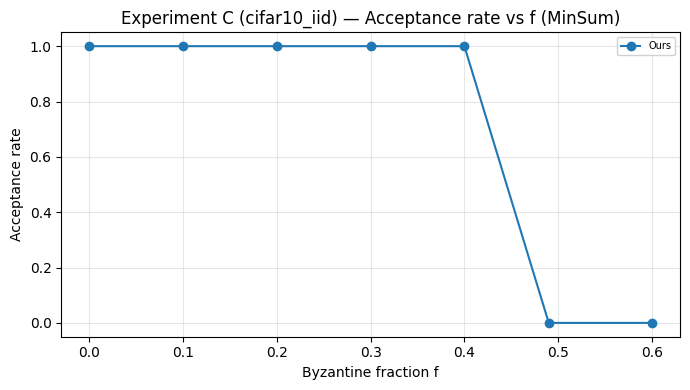


==================== Attack: LF ====================
Saved expC_cifar10_iid_smoke_lf.csv


,attack,method,f,acc,accept_rate
0,LF,DP-FedAvg,0.00,0.1748,NaN
1,LF,DP-FedAvg,0.10,0.1859,NaN
2,LF,DP-FedAvg,0.20,0.1778,NaN
3,LF,DP-FedAvg,0.30,0.1630,NaN
4,LF,DP-FedAvg,0.40,0.1584,NaN
5,LF,DP-FedAvg,0.49,0.1482,NaN
6,LF,DP-FedAvg,0.60,0.1418,NaN
7,LF,FedVRDP-style,0.00,0.1601,NaN
8,LF,FedVRDP-style,0.10,0.1594,NaN
9,LF,FedVRDP-style,0.20,0.1587,NaN


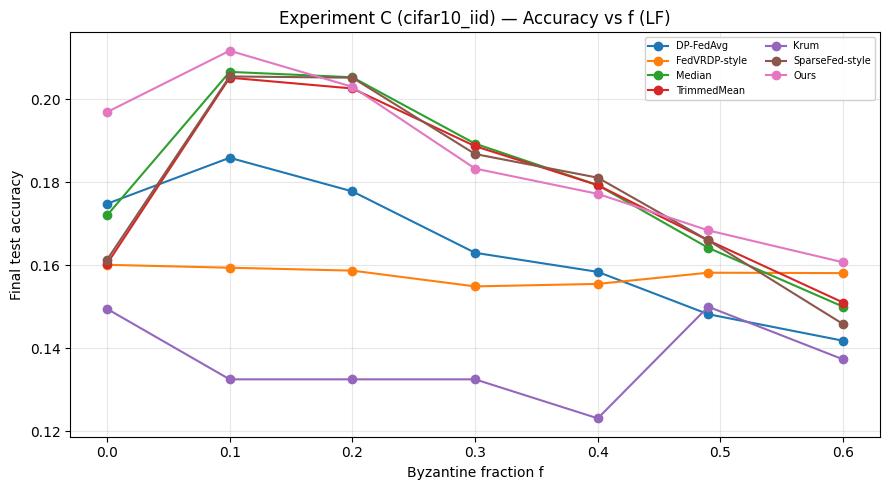

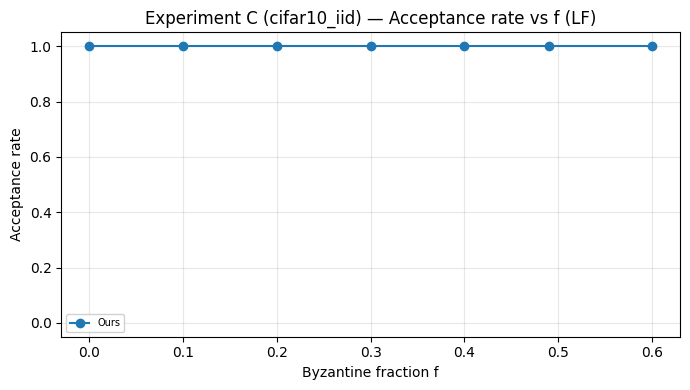


==================== Attack: FoE ====================
Saved expC_cifar10_iid_smoke_foe.csv


,attack,method,f,acc,accept_rate
0,FoE,DP-FedAvg,0.00,0.1748,NaN
1,FoE,DP-FedAvg,0.10,0.1859,NaN
2,FoE,DP-FedAvg,0.20,0.1716,NaN
3,FoE,DP-FedAvg,0.30,0.1630,NaN
4,FoE,DP-FedAvg,0.40,0.1368,NaN
5,FoE,DP-FedAvg,0.49,0.1100,NaN
6,FoE,DP-FedAvg,0.60,0.1005,NaN
7,FoE,FedVRDP-style,0.00,0.1601,NaN
8,FoE,FedVRDP-style,0.10,0.1593,NaN
9,FoE,FedVRDP-style,0.20,0.1576,NaN


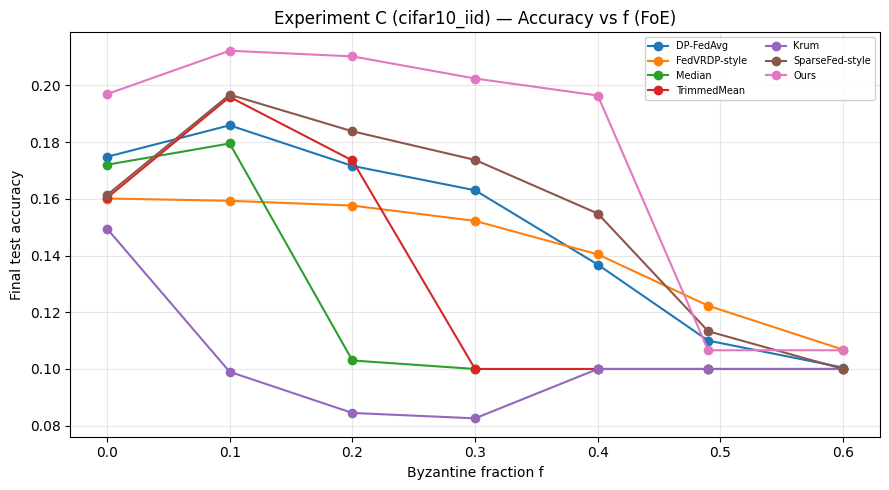

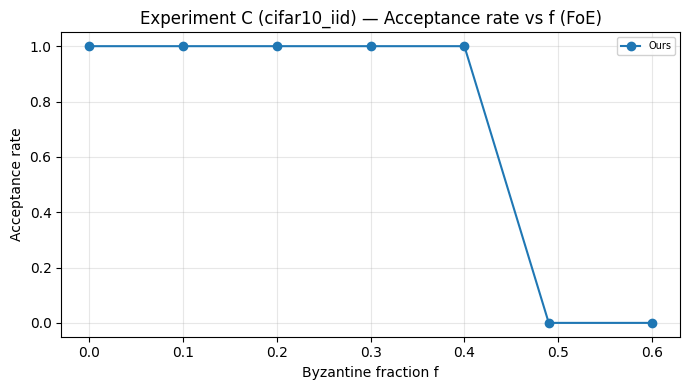


Saved expC_cifar10_iid_smoke_all_results.csv


,attack,method,f,acc,accept_rate
0,ALIE,DP-FedAvg,0.00,0.1748,NaN
1,ALIE,DP-FedAvg,0.10,0.1589,NaN
2,ALIE,DP-FedAvg,0.20,0.1361,NaN
3,ALIE,DP-FedAvg,0.30,0.1234,NaN
4,ALIE,DP-FedAvg,0.40,0.1140,NaN
...,...,...,...,...,...
289,SF,AG-PTR,0.20,0.2102,1.0
290,SF,AG-PTR,0.30,0.2024,1.0
291,SF,AG-PTR,0.40,0.1964,1.0
292,SF,AG-PTR,0.49,0.1066,0.0


In [19]:
# Cell 14 — Smoke test only: all attacks × all methods (CIFAR-10 IID)
# Methods:
#   AG-PTR, DP-FedAvg, FedVRDP-style, Median, TrimmedMean, Krum, SparseFed-style
# Attacks:
#   ALIE, SF, MinMax, MinSum, LF, FoE
#
# Output:
#   - one table per attack
#   - one accuracy chart per attack (all methods on one plot)
#   - one acceptance-rate chart per attack (AG-PTR only, shown as "Ours")

seed = 0
eps_total = 2.0
delta = 1e-5

f_list = [0.00, 0.10, 0.20, 0.30, 0.40, 0.49, 0.60]

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

# Attack params
ALIE_Z = 2.0
ALIE_DIR = -1.0
SF_SCALE = 5.0
FOE_SCALE = 1.0
LABEL_FLIP_SHIFT = 1

# AG-PTR params
RHO = 0.3
TAU = 35
R_PUB_AVG = 16
PUB_BATCH = 80
PUB_SCALE = 0.002
PUBLIC_EPOCHS = 2

# DP-FedAvg / FedVRDP-style params
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC_VR = 0.30

# SparseFed-style params
CLIP_C_SPARSE = 1.0
K_FRAC_SPARSE = 0.30

ATTACKS = [
    ("ALIE",   "alie"),
    ("SF",     "sf"),
    ("MinMax", "minmax"),
    ("MinSum", "minsum"),
    ("LF",     "lf"),
    ("FoE",    "foe"),
]

METHOD_ORDER = [
    "DP-FedAvg",
    "FedVRDP-style",
    "Median",
    "TrimmedMean",
    "Krum",
    "SparseFed-style",
    "AG-PTR",
]

LEGEND_LABELS = {
    "DP-FedAvg": "DP-FedAvg",
    "FedVRDP-style": "FedVRDP-style",
    "Median": "Median",
    "TrimmedMean": "TrimmedMean",
    "Krum": "Krum",
    "SparseFed-style": "SparseFed-style",
    "AG-PTR": "Ours",
}

EXPERIMENT_TAG = "cifar10_iid"

q = CLIENTS_PER_ROUND / len(clients)

sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)
eps_dp = epsilon_from_sigma_single(sigma_dp, q, ROUNDS, delta)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel
eps_ag = epsilon_from_sigma_two(sigma_sel, sigma_rel, q, ROUNDS, delta)

print("Experiment:", EXPERIMENT_TAG)
print("sigma_dp:", sigma_dp, "achieved eps≈", eps_dp)
print("sigma_ag sel/rel:", sigma_sel, sigma_rel, "achieved eps≈", eps_ag)
print(f"seed={seed}, rounds={ROUNDS}, local_epochs={LOCAL_EPOCHS}, batch_size={BATCH_SIZE}")
print(f"AG-PTR: rho={RHO}, tau={TAU}, R_pub_avg={R_PUB_AVG}, pub_batch={PUB_BATCH}, pub_scale={PUB_SCALE}")
print(f"ALIE: z={ALIE_Z}, dir={ALIE_DIR}")
print(f"SF scale={SF_SCALE}, FoE scale={FOE_SCALE}, LF shift={LABEL_FLIP_SHIFT}")
print(f"FedVRDP-style: clip_C={CLIP_C_VR}, k_frac={K_FRAC_VR}")
print(f"SparseFed-style: clip_C={CLIP_C_SPARSE}, k_frac={K_FRAC_SPARSE}")

all_rows = []

for attack_name, attack_key in ATTACKS:
    print(f"\n==================== Attack: {attack_name} ====================")
    attack_rows = []

    for f in f_list:
        acc_dp, _ = train_dp_fedavg_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_DP,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_vr, _ = train_fedvrdp_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC_VR,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_med, _ = train_median_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_tmean, _ = train_trimmedmean_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            trim_k=None,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_krum, _ = train_krum_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_sparse, _ = train_sparsefed_style_robust(
            seed, eps_total, f, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_SPARSE, k_frac=K_FRAC_SPARSE,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            show_progress=False
        )

        acc_ag, ar_ag = train_ag_ptr(
            seed, eps_total, f,
            sigma_sel, sigma_rel, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            rho=RHO, tau=TAU,
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            attack_type=attack_key,
            alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            sf_scale=SF_SCALE, foe_scale=FOE_SCALE,
            label_flip_shift=LABEL_FLIP_SHIFT,
            allow_zero=False,
            show_progress=False
        )

        attack_rows.extend([
            {"attack": attack_name, "method": "DP-FedAvg",       "f": f, "acc": acc_dp,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "FedVRDP-style",   "f": f, "acc": acc_vr,     "accept_rate": np.nan},
            {"attack": attack_name, "method": "Median",          "f": f, "acc": acc_med,    "accept_rate": np.nan},
            {"attack": attack_name, "method": "TrimmedMean",     "f": f, "acc": acc_tmean,  "accept_rate": np.nan},
            {"attack": attack_name, "method": "Krum",            "f": f, "acc": acc_krum,   "accept_rate": np.nan},
            {"attack": attack_name, "method": "SparseFed-style", "f": f, "acc": acc_sparse, "accept_rate": np.nan},
            {"attack": attack_name, "method": "AG-PTR",          "f": f, "acc": acc_ag,     "accept_rate": ar_ag},
        ])

    df_attack = pd.DataFrame(attack_rows)
    df_attack["method"] = pd.Categorical(df_attack["method"], categories=METHOD_ORDER, ordered=True)
    df_attack = df_attack.sort_values(["method", "f"]).reset_index(drop=True)

    df_attack.to_csv(f"expC_{EXPERIMENT_TAG}_smoke_{attack_key}.csv", index=False)
    print(f"Saved expC_{EXPERIMENT_TAG}_smoke_{attack_key}.csv")
    display(df_attack)

    # Accuracy chart: legend inside the plot
    fig, ax = plt.subplots(figsize=(9, 5))
    for method in METHOD_ORDER:
        sub = df_attack[df_attack["method"] == method]
        ax.plot(sub["f"], sub["acc"], marker="o", label=LEGEND_LABELS[method])
    ax.set_xlabel("Byzantine fraction f")
    ax.set_ylabel("Final test accuracy")
    ax.set_title(f"Experiment C ({EXPERIMENT_TAG}) — Accuracy vs f ({attack_name})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9, ncol=2)
    fig.tight_layout()
    plt.show()

    # Acceptance-rate chart: legend inside the plot
    fig, ax = plt.subplots(figsize=(7, 4))
    sub = df_attack[df_attack["method"] == "AG-PTR"]
    ax.plot(sub["f"], sub["accept_rate"], marker="o", label="Ours")
    ax.set_xlabel("Byzantine fraction f")
    ax.set_ylabel("Acceptance rate")
    ax.set_title(f"Experiment C ({EXPERIMENT_TAG}) — Acceptance rate vs f ({attack_name})")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, framealpha=0.9)
    fig.tight_layout()
    plt.show()

    all_rows.extend(attack_rows)

df_smoke_all = pd.DataFrame(all_rows)
df_smoke_all["method"] = pd.Categorical(df_smoke_all["method"], categories=METHOD_ORDER, ordered=True)
df_smoke_all = df_smoke_all.sort_values(["attack", "method", "f"]).reset_index(drop=True)

df_smoke_all.to_csv(f"expC_{EXPERIMENT_TAG}_smoke_all_results.csv", index=False)
print(f"\nSaved expC_{EXPERIMENT_TAG}_smoke_all_results.csv")
display(df_smoke_all)